<div align="center">

<h1>Trabalho – SDM (2025.2)</h1>  
<h3>Prof. Cristiano Fernandes</h3>  

<br>

<h3>Alunos:</h3>
<h4>Alessandra Malizia – 2512127</h4>
<h4>Luiz Felipe Rodrigues – 2511879</h4>

</div>

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import datetime as dt

from scipy.optimize import minimize
from scipy.special import expit, logit, gammaln
from scipy.stats import probplot, norm, poisson, nbinom, uniform

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def plot_forecast(y_obs, forecast_mean, forecast_ic, title="Previsão k-passos à frente"):
    """
    Plota série observada e previsão k-passos com intervalo de confiança.
    """
    T = len(y_obs)
    k = len(forecast_mean)
    forecast_idx = np.arange(T, T + k)

    plt.figure(figsize=(12, 5))
    plt.plot(np.arange(T), y_obs, label='Série Observada', lw=1.5, color='black')
    plt.plot(forecast_idx, forecast_mean, label='Previsão', lw=2, color='tab:blue')
    plt.fill_between(forecast_idx, forecast_ic[0], forecast_ic[1], color='tab:blue', alpha=0.3, label='IC 95%')

    plt.axvline(T - 1, color='grey', linestyle='--', lw=1)
    plt.xlabel("Tempo")
    plt.ylabel("Contagem")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [3]:
def plot_diagnostics(pit, quant_resid, pearson_resid, title='Diagnóstico do Modelo'):
    """
    Plota gráficos de diagnóstico: PIT, resíduos quantílicos e resíduos de Pearson.
    """
    T = len(pit)

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{title} – PIT e Resíduos', fontsize=16)

    sns.histplot(pit, bins=20, kde=False, ax=axs[0, 0], color='skyblue')
    axs[0, 0].set_title('Histograma do PIT')
    axs[0, 0].axhline(T / 20, color='red', linestyle='--')

    sns.histplot(quant_resid, bins=30, kde=True, ax=axs[0, 1])
    axs[0, 1].set_title('Resíduos Quantílicos')

    probplot(quant_resid, dist="norm", plot=axs[1, 0])
    axs[1, 0].set_title('QQ-Plot do Resíduo Quantílico')

    axs[1, 1].scatter(range(T), pearson_resid, alpha=0.7)
    axs[1, 1].set_title('Resíduos de Pearson')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Modelos GAS Hurdle

## 1. GAS Hurdle Poisson (GHP)

Diferentemente das distribuições Poisson e Binomial Negativa (NB) padrão — nas quais a probabilidade de observar zero é função da média e variância —, nas distribuições aumentadas para zeros (zero‑augmented), como a hurdle Poisson, a probabilidade de zero surge de um processo separado.

Na hurdle Poisson (HP), primeiro ocorre um **ensaio de Bernoulli**, que gera um zero com probabilidade  
$$
\pi_{t|t-1}.
$$

Se ocorrer “falha” no Bernoulli, o valor positivo é amostrado de uma **Poisson truncada em zero**.

A função de massa de probabilidade da HP dinâmica é:

$$
p(y_t \mid \lambda_{t|t-1}, \pi_{t|t-1}) =
\begin{cases}
\pi_{t|t-1}, & y_t = 0, \\[8pt]
(1 - \pi_{t|t-1})
\dfrac{\lambda_{t|t-1}^{y_t} e^{-\lambda_{t|t-1}}}{y_t! \left(1 - e^{-\lambda_{t|t-1}}\right)}, 
& y_t > 0.
\end{cases}
\tag{15}
$$

com  
- $\lambda_{t|t-1} > 0$,  
- $\pi_{t|t-1} \in (0,1)$.

### 1.1 Média e Variância

**Média:**

$$
\mathbb{E}_{t-1}[y_t] = 
\frac{\lambda_{t|t-1}}{1 - e^{-\lambda_{t|t-1}}}(1 - \pi_{t|t-1})
$$

**Variância:**

$$
\operatorname{Var}_{t-1}[y_t] =
\lambda_{t|t-1}(1 - \pi_{t|t-1})
\frac{1}{1 - e^{-\lambda_{t|t-1}}}
\left[
1 +
\frac{\lambda_{t|t-1} \pi_{t|t-1}}{1 - e^{-\lambda_{t|t-1}}} - \frac{\lambda_{t|t-1}}{e^{\lambda_{t|t-1}}(1 - e^{-\lambda_{t|t-1}})}
\right]
\tag{16}
$$

### 1.2 Dinâmica dos parâmetros

Faremos o passo a passo na derivação das dinâmicas do modelo GHP, calcularemos tanto com a função _link_ identidade, como também reparametrizada conforme as funções _link_ abaixo

$$
h_1(\pi_{t|t-1}) = \tilde{\pi}_{t|t-1} = \ln\left( \frac{\pi_{t|t-1}}{1 - \pi_{t|t-1}} \right), \quad
h_2(\lambda_{t|t-1}) = \tilde{\lambda}_{t|t-1} = \ln(\lambda_{t|t-1})
$$

#### 1.2.1 Gradiente da função de probabilidade condicional

Como visto, a função de probabilidade condicional é uma mistura:

$$
\ln(p(y_t \mid \lambda_{t|t-1}, \pi_{t|t-1})) =
\begin{cases}
\ln(\pi_{t|t-1}), & \text{se } y_t = 0 \\\\
\ln(1 - \pi_{t|t-1}) - \lambda_{t|t-1} + y_t \ln(\lambda_{t|t-1}) - \ln(y_t!) - \ln(1 - \exp(-\lambda_{t|t-1})), & \text{se } y_t > 0
\end{cases}
$$

Com isso, temos que

- Para $y_t = 0$:

$$
\nabla_{y_t = 0} =
\begin{bmatrix}
\nabla_{y_t = 0}^{\pi_{t|t-1}} \\
\nabla_{y_t = 0}^{\lambda_{t|t-1}}
\end{bmatrix}
= \begin{bmatrix}
\frac{1}{\pi_{t|t-1}} \\
0
\end{bmatrix}
$$

- Para $y_t > 0$:

$$
\nabla_{y_t > 0} =
\begin{bmatrix}
\nabla_{y_t > 0}^{\pi_{t|t-1}} \\
\nabla_{y_t > 0}^{\lambda_{t|t-1}}
\end{bmatrix}
=\begin{bmatrix}
\frac{-1}{1 - \pi_{t|t-1}} \\\\
\frac{y_t - \lambda_{t|t-1}}{\lambda_{t|t-1}} - \frac{e^{-\lambda_{t|t-1}}}{1 - e^{-\lambda_{t|t-1}}}
\end{bmatrix}
$$

#### 1.2.2 Informação de Fisher

Para a informação de Fisher, temos que

$$
\mathcal{I}_{t|t-1} = \mathbb{E}_{t-1}
\left[
\begin{bmatrix}
(\nabla^{\pi_{t|t-1}})^2 & \nabla^{\pi_{t|t-1}} \nabla^{\lambda_{t|t-1}} \\
\nabla^{\lambda_{t|t-1}} \nabla^{\pi_{t|t-1}} & (\nabla^{\lambda_{t|t-1}})^2
\end{bmatrix}
\right]
=
\begin{bmatrix}
\frac{1}{\pi_{t|t-1}(1 - \pi_{t|t-1})} & 0 \\\\
0 & \frac{ (1 - \pi_{t|t-1}) [ 1 - e^{-\lambda_{t|t-1}} - \lambda_{t|t-1} e^{-\lambda_{t|t-1}} ] }{(1 - e^{-\lambda_{t|t-1}})^2 \lambda_{t|t-1}}
\end{bmatrix}
$$

#### 1.2.3 Jacobiana das funções _link_

Dadas as funções $h_1$ e $h_2$ definidas acima, temos que 

$$
\tilde{h}_{t|t-1} =
\begin{bmatrix}
\frac{\partial h_1}{\partial \pi_{t|t-1}} & 0 \\\\
0 & \frac{\partial h_2}{\partial \lambda_{t|t-1}}
\end{bmatrix} = 
\begin{bmatrix}
\frac{1}{\pi_{t|t-1}(1 - \pi_{t|t-1})} & 0 \\\\
0 & \frac{1}{\lambda_{t|t-1}}
\end{bmatrix}
$$

Com isso, a inversa de $\tilde{h}_{t|t-1}$ é dada por

$$
\tilde{h}_{t|t-1}^{-1} =
\begin{bmatrix}
\pi_{t|t-1}(1 - \pi_{t|t-1}) & 0 \\\\
0 & \lambda_{t|t-1}
\end{bmatrix}
$$

#### 1.2.4 _Score_ do GHP

Encontramos $\nabla_{y_t = 0}$ e $\nabla_{y_t > 0}$, que foram calculadas com base na função _link_ identidade. Agora encontraremos $\tilde{\nabla}_{y_t = 0}$ e $\tilde{\nabla}_{y_t > 0}$. para que possamos encontrar o _score_ e finalmente chegarmos à dinâmica dos parâmetros.

- Para $y_t = 0$:

$$
\tilde{\nabla}_{y_t = 0} =
\tilde{h}_{t|t-1}^{-1} \nabla_{y_t = 0} =
\begin{bmatrix}
1 - \pi_{t|t-1} \\\\
0
\end{bmatrix}
$$

- Para $y_t > 0$:

$$
\tilde{\nabla}_{y_t > 0} =
\tilde{h}_{t|t-1}^{-1} \nabla_{y_t > 0} =
\begin{bmatrix}
- \pi_{t|t-1} \\\\
y_t - \lambda_{t|t-1} - \frac{ \lambda_{t|t-1} e^{-\lambda_{t|t-1}} }{ 1 - e^{-\lambda_{t|t-1}}}
\end{bmatrix}
$$

Abaixo, encontramos a Informação de Fischer reparametrizada:

$$
\tilde{\mathcal{I}}_{t|t-1} =
\tilde{h}_{t|t-1}^{-1} \mathcal{I}_{t|t-1} \tilde{h}_{t|t-1}^{-1}
=
\begin{bmatrix}
\pi_{t|t-1}(1 - \pi_{t|t-1}) & 0 \\\\
0 & \frac{ \lambda_{t|t-1} (1 - \pi_{t|t-1}) [ 1 - e^{-\lambda_{t|t-1}} - \lambda_{t|t-1} e^{-\lambda_{t|t-1}} }{(1 - e^{-\lambda_{t|t-1}})^2}
\end{bmatrix}
$$

Com isso, podemos encontrar os _scores_, conforme equação geral abaixo

$$
\tilde{s}_{t|t-1}
=
\left( \tilde{\mathcal{I}}_{t|t-1} \right)^{-d} \tilde{\nabla}_{t|t-1}
$$

Com isso, temos que

- Para $y_t = 0$:

$$
\tilde{\nabla}_{t|t-1}^{(y=0)} =
\begin{bmatrix}
1 - \pi_{t|t-1} \\
0
\end{bmatrix}
\qquad
\tilde{\mathcal{I}}_{t|t-1} =
\begin{bmatrix}
\pi_{t|t-1}(1 - \pi_{t|t-1}) & 0 \\
0 & \mathcal{I}_{\lambda}
\end{bmatrix}
$$

Logo, o score reparametrizado para d=0 é:

$$
\tilde{s}_{t|t-1}^{(y=0)} =
\begin{bmatrix}
\displaystyle 1 - \pi_{t|t-1} \\
0
\end{bmatrix}
$$

- Para $y_t > 0$:

$$
\tilde{\nabla}_{t|t-1}^{(y>0)} =
\begin{bmatrix}
- \pi_{t|t-1} \\
y_t - \lambda_{t|t-1} - \frac{ \lambda_{t|t-1} e^{-\lambda_{t|t-1}} }{ 1 - e^{-\lambda_{t|t-1}}}
\end{bmatrix}
$$

e

$$
\tilde{\mathcal{I}}_{t|t-1} =
\tilde{h}_{t|t-1}^{-1} \mathcal{I}_{t|t-1} \tilde{h}_{t|t-1}^{-1}
=
\begin{bmatrix}
\pi_{t|t-1}(1 - \pi_{t|t-1}) & 0 \\\\
0 & \frac{ \lambda_{t|t-1} (1 - \pi_{t|t-1}) [ 1 - e^{-\lambda_{t|t-1}} - \lambda_{t|t-1} e^{-\lambda_{t|t-1}} }{(1 - e^{-\lambda_{t|t-1}})^2}
\end{bmatrix}
$$

Para d=0, o score reparametrizado torna-se:

$$
\tilde{s}_{t|t-1}^{(y>0)} =
\begin{bmatrix}
\displaystyle - \pi_{t|t-1} \\
\displaystyle y_t - \lambda_{t|t-1} - \frac{ \lambda_{t|t-1} e^{-\lambda_{t|t-1}} }{ 1 - e^{-\lambda_{t|t-1}}}
\end{bmatrix}
$$

Com isso, utilizamos os scores reparametrizados acima para atualizar $\tilde{\pi}_{t|t-1}$ e $\tilde{\lambda}_{t|t-1}$ via uma estrutura autoregressiva do tipo AR(1) com inovação do tipo GAS.

##### 1.2.4.1 Probabilidade de zero — $\tilde{\pi}_{t|t-1}$

$$
\tilde{\pi}_{t+1|t}
=
\delta_\pi
+
\beta_\pi \cdot \tilde{\pi}_{t|t-1}
+
\rho_\pi \cdot \tilde{s}_{\pi,t|t-1}
$$

onde:

- $\delta_\pi$: constante
- $\beta_\pi$: persistência
- $\rho_\pi$: peso do score
- $\tilde{s}_{\pi,t|t-1}$: componente do score referente a $\pi$

##### 1.2.4.2 Intensidade — $\tilde{\lambda}_{t|t-1}$

$$
\tilde{\lambda}_{t+1|t}
=
\delta_\lambda
+
\beta_\lambda \cdot \tilde{\lambda}_{t|t-1}
+
\rho_\lambda \cdot \tilde{s}_{\lambda,t|t-1}
$$

onde:

- $\tilde{s}_{\lambda,t|t-1}$: componente do score referente a $\lambda$

### 1.3 Simulação

Abaixo simularemos o GHP.

In [4]:
def sigmoid(x):
    return expit(x)

def clip_logit(x, bounds=(-6, 6)):
    return np.clip(x, *bounds)

def clip_exp(x, bounds=(-5, 4)):
    return np.clip(np.exp(x), np.exp(bounds[0]), np.exp(bounds[1]))

In [16]:
def score_ghp(y, lambda_, pi):
    """
    Calcula o score reparametrizado para o modelo GAS Hurdle Poisson (GHP).
    Retorna os dois componentes: score_pi, score_lambda
    """
    if y == 0:
        score_pi = 1 - pi
        score_lambda = 0.0
    else:
        numer = lambda_ * np.exp(-lambda_)
        denom = 1 - np.exp(-lambda_)
        adjustment = lambda_ + numer / denom

        score_pi = -pi
        score_lambda = y - adjustment

    return score_pi, score_lambda

In [6]:
def filter_ghp(params, y, loglam_bounds=(-5, 4), logitpi_bounds=(-6, 6)):
    """
    Aplica o filtro GAS Hurdle Poisson (GHP), retornando caminhos filtrados.
    """
    # delta_lambda, beta_lambda, rho_lambda, delta_pi, beta_pi, rho_pi = params
    lambda_tilde0 = params['lambda_tilde']
    pi_tilde0     = params['pi_tilde']
    delta_lambda  = params['delta_lambda']
    beta_lambda   = params['beta_lambda']
    rho_lambda    = params['rho_lambda']
    delta_pi      = params['delta_pi']
    beta_pi       = params['beta_pi']
    rho_pi        = params['rho_pi']

    T = len(y)
    lambda_tilde = np.zeros(T)
    pi_tilde     = np.zeros(T)
    lambda_t     = np.zeros(T)
    pi_t         = np.zeros(T)
    score_lambda = np.zeros(T)
    score_pi     = np.zeros(T)

    lambda_tilde[0] = lambda_tilde0
    pi_tilde[0]     = pi_tilde0

    for t in range(T):
        lambda_t[t] = np.exp(lambda_tilde[t])
        pi_t[t]     = expit(pi_tilde[t])

        if t < T - 1:
            # Score reparametrizado
            s_tilde_pi, s_tilde_lambda = score_ghp(y[t], lambda_t[t], pi_t[t])

            score_pi[t]     = s_tilde_pi
            score_lambda[t] = s_tilde_lambda

            # Atualização GAS(1,1)
            lambda_tilde[t+1] = np.clip(delta_lambda + rho_lambda * score_lambda[t] + beta_lambda * lambda_tilde[t], *loglam_bounds)
            pi_tilde[t+1]     = np.clip(delta_pi     + rho_pi     * score_pi[t]     + beta_pi     * pi_tilde[t],     *logitpi_bounds)

    return lambda_t, pi_t, lambda_tilde, pi_tilde, score_lambda, score_pi

In [7]:
def simulate_ghp(n_obs, params, seed=None, lambda_max=50):
    """
    Simula uma série GHP com parâmetros dados.
    """
    if seed is not None:
        np.random.seed(seed)

    # delta_lambda, beta_lambda, rho_lambda, delta_pi, beta_pi, rho_pi = params
    lambda_tilde = params['lambda_tilde']
    pi_tilde     = params['pi_tilde']
    delta_lambda = params['delta_lambda']
    beta_lambda  = params['beta_lambda'] 
    rho_lambda   = params['rho_lambda']
    delta_pi     = params['delta_pi']
    beta_pi      = params['beta_pi']
    rho_pi       = params['rho_pi']

    y = np.zeros(n_obs, dtype=int)
    lambda_t = np.zeros(n_obs)
    pi_t     = np.zeros(n_obs)
    f_lambda = lambda_tilde
    f_pi     = pi_tilde
    
    tolerancia = 0.001

    for t in range(n_obs):
        lam = np.clip(np.exp(f_lambda), tolerancia, lambda_max)
        pi0 = expit(f_pi)

        lambda_t[t] = lam
        pi_t[t]     = np.clip(pi0, tolerancia, 1 - tolerancia)

        u = np.random.rand()
        if u < pi_t[t]:
            y[t] = 0
        else:
            while True:
                z = np.random.poisson(lam)
                if z > 0:
                    y[t] = z
                    break

        score_pi, score_lambda = score_ghp(y[t], lam, pi_t[t])

        f_lambda = np.clip(delta_lambda + rho_lambda * score_lambda + beta_lambda * f_lambda, -5, 4)
        f_pi     = np.clip(delta_pi     + rho_pi     * score_pi     + beta_pi     * f_pi,     -6, 6)

    return y, lambda_t, pi_t

In [17]:
n_obs = 300
series_list = []
param_list = []

rng = np.random.default_rng(42)

for i in range(5):
    params_i = {
        'lambda_tilde': round(rng.uniform(0, 1), 2),
        'pi_tilde': round(rng.uniform(0, 0.4), 2),
        'delta_lambda': round(rng.uniform(-0.5, 0.5), 2),
        'beta_lambda': round(rng.uniform(-0.95, 0.95), 2),
        'rho_lambda':  round(rng.uniform(0.5, 0.95), 2),
        'delta_pi': round(rng.uniform(-0.5, 0.5), 2),
        'beta_pi': round(rng.uniform(-0.95, 0.95), 2),
        'rho_pi':  round(rng.uniform(0.5, 0.95), 2),
    }

    y_i, lam_i, pi_i = simulate_ghp(n_obs, params_i, seed=123 + i)
    series_list.append(y_i)
    param_list.append(params_i)

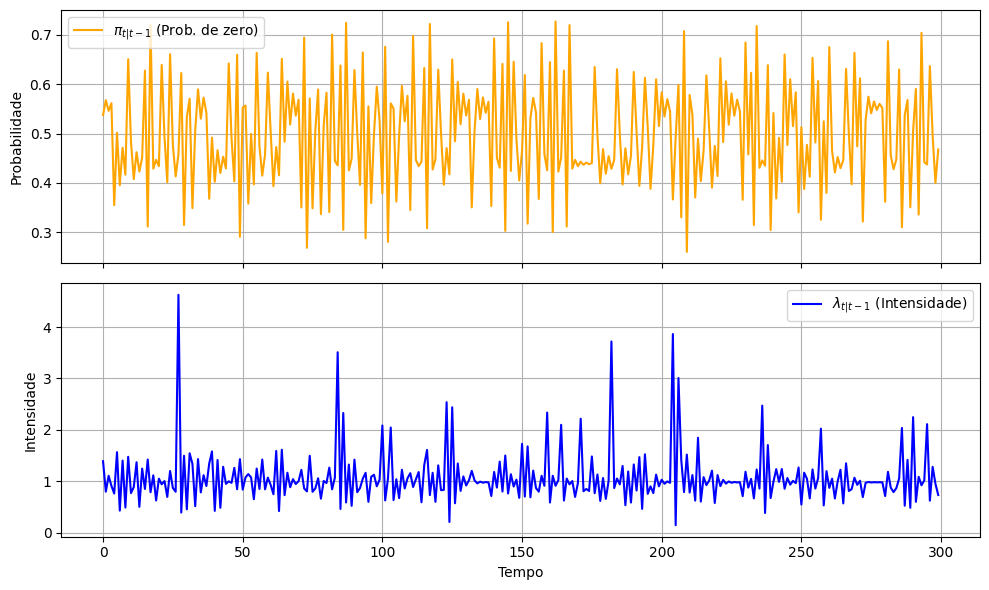

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(pi_i, label=r'$\pi_{t|t-1}$ (Prob. de zero)', color='orange')
ax[0].set_ylabel('Probabilidade')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(lam_i, label=r'$\lambda_{t|t-1}$ (Intensidade)', color='blue')
ax[1].set_ylabel('Intensidade')
ax[1].set_xlabel('Tempo')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

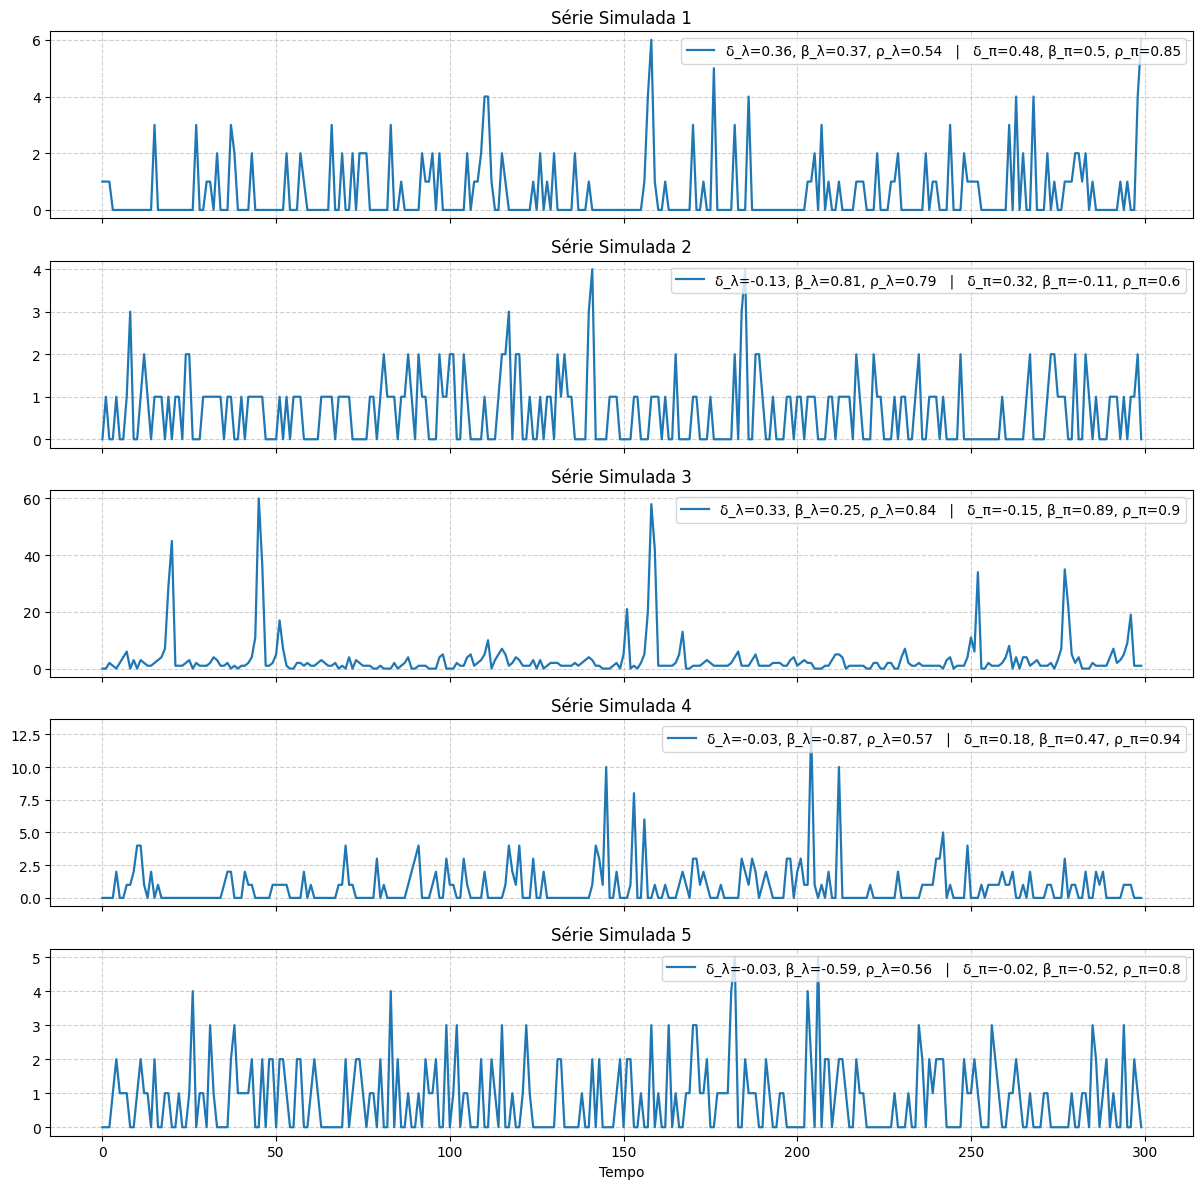

In [19]:
fig, axs = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

for i in range(5):
    s = series_list[i]
    p = param_list[i]

    axs[i].plot(s, lw=1.6)

    legend_text = (
        f"δ_λ={p['delta_lambda']}, β_λ={p['beta_lambda']}, ρ_λ={p['rho_lambda']}   |   "
        f"δ_π={p['delta_pi']}, β_π={p['beta_pi']}, ρ_π={p['rho_pi']}"
    )

    axs[i].legend([legend_text], loc='upper right')
    axs[i].set_title(f"Série Simulada {i+1}")
    axs[i].grid(True, linestyle='--', alpha=0.6)

axs[-1].set_xlabel("Tempo")
plt.tight_layout()
plt.show()

### 1.4 Ajustando modelo GHP

Vimos que o log da probabilidade no modelo GHP é dada por

$$
\ln(p(y_t \mid Y_{t-1}, \lambda_{t|t-1}, \pi_{t|t-1})) =
\begin{cases}
\ln(\pi_{t|t-1}), & \text{se } y_t = 0 \\\\
\ln(1 - \pi_{t|t-1}) - \lambda_{t|t-1} + y_t \ln(\lambda_{t|t-1}) - \ln(y_t!) - \ln(1 - \exp(-\lambda_{t|t-1})), & \text{se } y_t > 0
\end{cases}
$$

Com isso, a log-verossimilhança do modelo GHP é dada pelo seguinte somatório

$$
\ell(\theta)
=
\sum_{t=1}^T \ln p(y_t \mid \mathcal{F}_{t-1}, \theta)
$$

Além disso, os parâmetros $\pi_{t|t-1}$ e $\lambda_{t|t-1}$, cuja dinâmica definimos anteriormente, tem a seguinte recorrência

$$
\tilde{\pi}_{t+1|t} = \delta_\pi + \beta_\pi \cdot \tilde{\pi}_{t|t-1} + \rho_\pi \cdot \tilde{s}_{\pi, t|t-1}
\quad \Rightarrow \quad
\pi_{t|t-1} = \text{expit}(\tilde{\pi}_{t|t-1})
$$

$$
\tilde{\lambda}_{t+1|t} = \delta_\lambda + \beta_\lambda \cdot \tilde{\lambda}_{t|t-1} + \rho_\lambda \cdot \tilde{s}_{\lambda, t|t-1}
\quad \Rightarrow \quad
\lambda_{t|t-1} = \exp(\tilde{\lambda}_{t|t-1})
$$

Com isso, o vetor de parâmetros estimado por MLE é:

$$
\Theta =
\left\{
\tilde{\lambda}_{1|0}, \,
\tilde{\pi}_{1|0}, \,
\delta_\pi, \,
\beta_\pi, \,
\rho_\pi, \,
\delta_\lambda, \,
\beta_\lambda, \,
\rho_\lambda
\right\}
\in
\mathbb{R}^6
$$

Com as restrições usuais:

- $\beta_\pi, \beta_\lambda \in (-1, 1)$
- $\rho_\pi, \rho_\lambda > 0$

In [20]:
def ghp_scores(y, lam, pi):
    """
    Retorna os scores reparametrizados (tilde-s) do modelo GHP.
    Score é um VETOR de dimensão 2:
        [score_pi , score_lambda]
    conforme fórmulas (18) e (19)
    """
    if y == 0:
        score_pi = 1 - pi
        score_lam = 0.0
    else:
        # Poisson truncada
        trunc_factor = lam + lam * np.exp(-lam) / (1 - np.exp(-lam))
        score_pi = -pi
        score_lam = y - trunc_factor

    return score_pi, score_lam

In [11]:
def neg_loglik_ghp(params, y):
    """
    Log-verossimilhança negativa do modelo GAS Hurdle Poisson (GHP)
    com a nova parametrização:
        delta_lambda, beta_lambda, rho_lambda,
        delta_pi,     beta_pi,     rho_pi
    """
    # desempacotar parâmetros
    lambda_tilde, pi_tilde, delta_lambda, beta_lambda, rho_lambda, delta_pi, beta_pi, rho_pi = params

    # -------------------------------------------
    # 1. Restrições estruturais
    # -------------------------------------------
    if not (-1 < beta_lambda < 1 and -1 < beta_pi < 1):
        return np.inf

    if not (rho_lambda > 0 and rho_pi > 0):
        return np.inf

    # -------------------------------------------
    # 2. Executar o filtro para obter lambda_t|t-1 e pi_t|t-1
    # -------------------------------------------
    params_dict = {
        'lambda_tilde': lambda_tilde,
        'pi_tilde': pi_tilde,
        'delta_lambda': delta_lambda,
        'beta_lambda': beta_lambda,
        'rho_lambda': rho_lambda,
        'delta_pi': delta_pi,
        'beta_pi': beta_pi,
        'rho_pi':  rho_pi,
    }
    lambda_t, pi_t, _, _, _, _ = filter_ghp(params_dict, y)

    # -------------------------------------------
    # 3. Construção da log-verossimilhança
    # -------------------------------------------
    loglik = 0.0
    T = len(y)

    for t in range(T):
        lam = lambda_t[t]
        pi0 = pi_t[t]

        if y[t] == 0:
            # massa total do zero na hurdle Poisson
            loglik += np.log(pi0)
        else:
            # log pmf Poisson
            pois = y[t] * np.log(lam) - lam - gammaln(y[t] + 1)

            # ajustar truncação em zero
            pois_trunc = pois - np.log(1 - np.exp(-lam))

            # log-likelihood final
            loglik += np.log(1 - pi0) + pois_trunc

    return -loglik

In [21]:
serie_indice = 0
y_obs = series_list[serie_indice]
n = len(y_obs)
parametros_originais = param_list[serie_indice]

# Chute inicial sensato
x0 = np.array([0.1, 0.1, 0.1, 0.1, 0.9, 0.1, 0.1, 0.9])

bounds = [
    (-2, 2),
    (-2, 2),
    (-2, 2),
    (-0.95, 0.95),
    (0, 1),
    (-2, 2),
    (-0.95, 0.95),
    (0, 1)
]

result = minimize(
    neg_loglik_ghp,
    x0,
    args=(y_obs,),
    method="L-BFGS-B",
    bounds=bounds
)

### 1.5 Resultados

#### 1.5.1 Comparando os parâmetros

Abaixo, mostramos os valores originais e estimados dos parametros.

In [22]:
theta_hat = result.x
print("\n==== Parâmetros Estimados (MLE) ====")
print(f"delta_lambda={theta_hat[2]:.4f}, beta_lambda={theta_hat[3]:.4f}, rho_lambda={theta_hat[4]:.4f}")
print(f"delta_pi={theta_hat[5]:.4f}, beta_pi={theta_hat[6]:.4f}, rho_pi={theta_hat[7]:.4f}")

print()
print("-" * 65)

print("\n==== Parâmetros Originais ====")
print(f"delta_lambda={parametros_originais['delta_lambda']:.4f}, beta_lambda={parametros_originais['beta_lambda']:.4f}, rho_lambda={parametros_originais['rho_lambda']:.4f}")
print(f"delta_pi={parametros_originais['delta_pi']:.4f}, beta_pi={parametros_originais['beta_pi']:.4f}, rho_pi={parametros_originais['rho_pi']:.4f}")


==== Parâmetros Estimados (MLE) ====
delta_lambda=0.1000, beta_lambda=0.1000, rho_lambda=0.9000
delta_pi=0.1000, beta_pi=0.1000, rho_pi=0.9000

-----------------------------------------------------------------

==== Parâmetros Originais ====
delta_lambda=0.3600, beta_lambda=0.3700, rho_lambda=0.5400
delta_pi=0.4800, beta_pi=0.5000, rho_pi=0.8500


#### 1.6.2 Mostrando os resultados

Seguem os gráficos para comparaçãos dos resultados e forecast um passo a frente.

In [23]:
theta_hat_dict = {
    'lambda_tilde': theta_hat[0],
    'pi_tilde': theta_hat[1],
    'delta_lambda': theta_hat[2],
    'beta_lambda': theta_hat[3],
    'rho_lambda': theta_hat[4],
    'delta_pi': theta_hat[5],
    'beta_pi': theta_hat[6],
    'rho_pi':  theta_hat[7],
}

lambda_hat, pi_hat, f_lambda_hat, f_pi_hat, score_lambda, score_pi = filter_ghp(theta_hat_dict, y_obs)

In [36]:
def insample_forecast_ghp(y, lambda_t, pi_t, title='In-sample: Observado vs E[y|t-1]'):
    """
    Calcula a esperança condicional in-sample da Hurdle Poisson segundo
    E_{t-1}[y_t] = (lambda_t / (1 - exp(-lambda_t))) * (1 - pi_t)
    Plota observado vs previsão e retorna as métricas RMSE, MAE e MAPE.
    """
    
    exp_neg_lam = np.exp(-np.clip(lambda_t, None, 700))
    denom = 1.0 - exp_neg_lam
    denom = np.maximum(denom, 1e-8)

    # valor esperado
    mu_trunc = lambda_t / denom                
    yhat = mu_trunc * (1.0 - pi_t)       

    # métricas
    resid = y - yhat
    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))
    metrics = {'rmse': float(rmse), 'mae': float(mae)}

    # plot
    fig, ax = plt.subplots(figsize=(12,4.5))
    ax.plot(y, label='Observado (y)', linewidth=1, alpha=0.9)
    ax.plot(yhat, label=r'E$_{t-1}[y_t]$', linewidth=1.4, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel('t')
    ax.set_ylabel('Contagem')
    ax.legend()
    ax.grid(alpha=0.25)

    # mostrar métricas no gráfico
    textstr = (f"RMSE = {metrics['rmse']:.3f}\n"
               f"MAE  = {metrics['mae']:.3f}\n")
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.show()

    return yhat, metrics

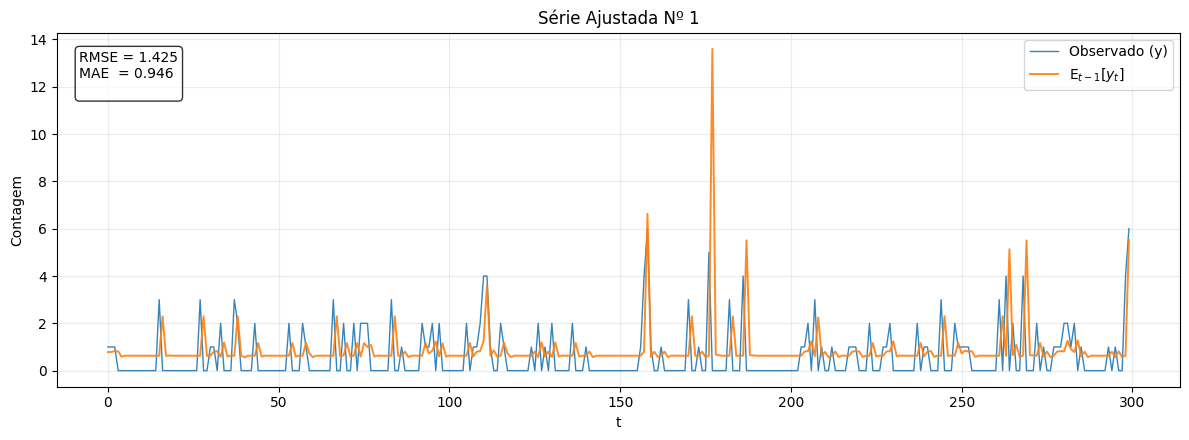

In [37]:
y_hat, metrics = insample_forecast_ghp(
    y_obs, lambda_hat, pi_hat,
    title=f"Série Ajustada Nº {serie_indice+1}"
)

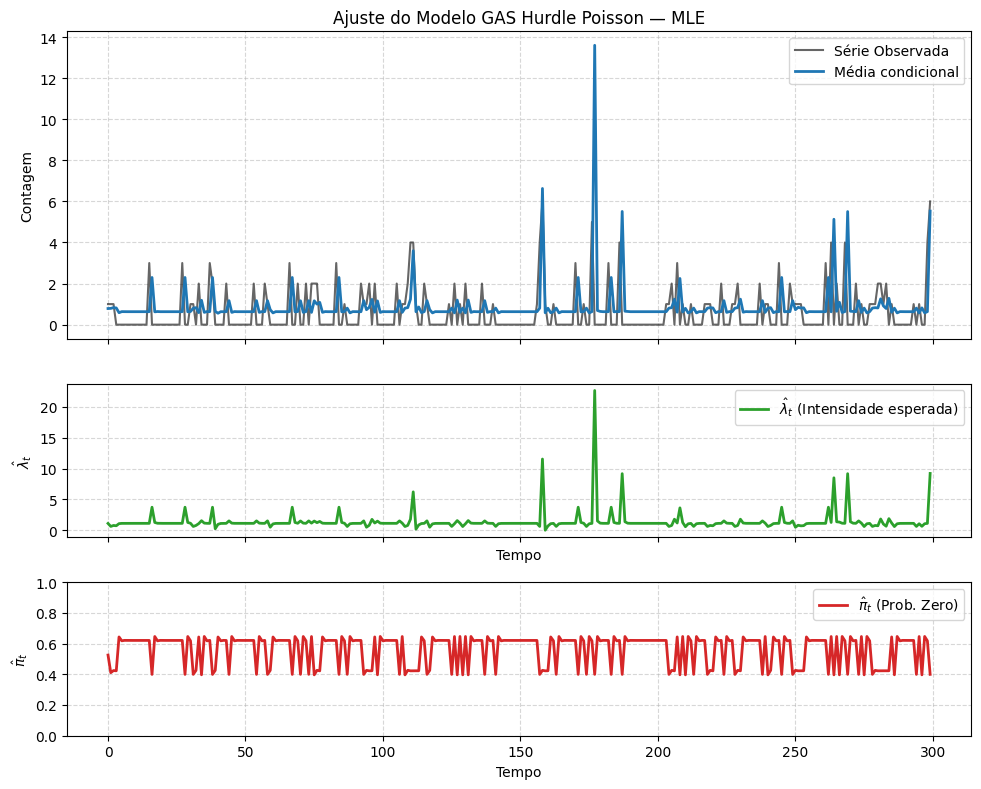

In [40]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [2,1,1]})

# --- Gráfico superior: y_obs e lambda_hat ---
ax1.plot(y_obs, label='Série Observada', lw=1.5, color='black', alpha=0.6)
ax1.plot(y_hat, label=r'Média condicional', lw=2, color='tab:blue')
ax1.set_ylabel("Contagem", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')
ax1.set_title("Ajuste do Modelo GAS Hurdle Poisson — MLE")

# --- Gráfico inferior: lambda_hat ---
ax2.plot(lambda_hat, label=r'$\hat{\lambda}_t$ (Intensidade esperada)', lw=2, color='tab:green')
ax2.set_xlabel("Tempo")
ax2.set_ylabel(r"$\hat{\lambda}_t$")
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

# --- Gráfico inferior: pi_hat ---
ax3.plot(pi_hat, label=r'$\hat{\pi}_t$ (Prob. Zero)', lw=2, color='tab:red')
ax3.set_xlabel("Tempo")
ax3.set_ylabel(r"$\hat{\pi}_t$")
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.set_ylim(0, 1)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 1.6 Diagnóstico do GHP

In [25]:
def diagnostics_ghp(y, lambda_t, pi_t, title='Diagnóstico do Modelo GHP'):
    T = len(y)
    pit = np.zeros(T)
    quant_resid = np.zeros(T)
    pearson_resid = np.zeros(T)

    for t in range(T):
        y_t = y[t]
        lam = lambda_t[t]
        pi = pi_t[t]
        p0 = np.exp(-lam)
        p0 = np.clip(p0, 1e-12, 1 - 1e-12)

        if y_t == 0:
            # PIT uniforme em [0, pi_t]
            pit[t] = np.random.uniform(0, pi)
            quant_resid[t] = norm.ppf(pit[t])

            # Esperança e variância condicional (y_t = 0)
            mu = (1 - pi) * lam / (1 - p0)
            var_trunc = lam * (1 + lam * p0 / (1 - p0))  # Var[Z|Z>0]
            var = (1 - pi) * (var_trunc + pi * (mu / (1 - pi))**2) - mu**2
            var = max(var, 1e-8)
            pearson_resid[t] = (0 - mu) / np.sqrt(var)

        else:
            # PIT com CDF da Poisson truncada
            def F_trunc(k):
                return (poisson.cdf(k, lam) - p0) / (1 - p0)

            F_lo = F_trunc(y_t - 1) if y_t > 1 else 0
            F_hi = F_trunc(y_t)
            u = np.random.uniform()
            pit[t] = pi + (1 - pi) * (F_lo + u * (F_hi - F_lo))
            quant_resid[t] = norm.ppf(pit[t])

            # Esperança e variância condicional (y_t > 0)
            mu = (1 - pi) * lam / (1 - p0)
            var_trunc = lam * (1 + lam * p0 / (1 - p0))
            var = (1 - pi) * (var_trunc + pi * (mu / (1 - pi))**2) - mu**2
            var = max(var, 1e-3)
            pearson_resid[t] = (y_t - mu) / np.sqrt(var)

    # Gráficos
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{title} – PIT e Resíduos', fontsize=16)

    sns.histplot(pit, bins=20, kde=False, ax=axs[0, 0], color='skyblue')
    axs[0, 0].set_title('Histograma do PIT')
    axs[0, 0].axhline(T / 20, color='red', linestyle='--')

    sns.histplot(quant_resid, bins=30, kde=True, ax=axs[0, 1])
    axs[0, 1].set_title('Resíduos Quantílicos')

    probplot(quant_resid, dist="norm", plot=axs[1, 0])
    axs[1, 0].set_title('QQ-Plot do Resíduo Quantílico')

    axs[1, 1].scatter(range(T), pearson_resid, alpha=0.7)
    axs[1, 1].set_title('Resíduos de Pearson')
    axs[1, 1].axhline(0, color='black', linestyle='--', linewidth=1)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return pit, quant_resid, pearson_resid

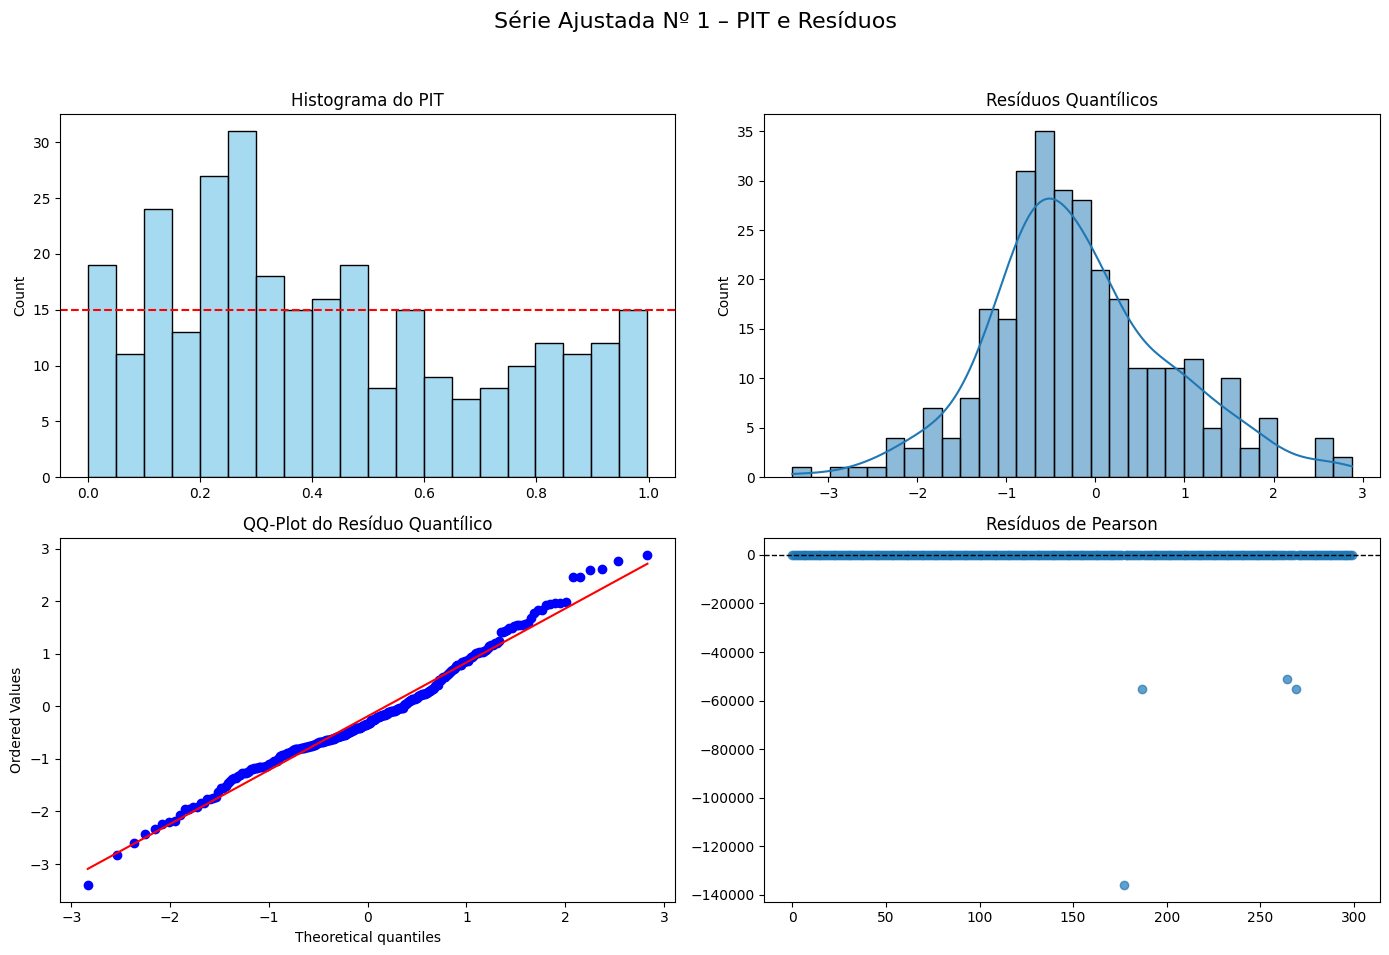

In [26]:
pit_vals, qresid, presid = diagnostics_ghp(
    y_obs, lambda_hat, pi_hat,
    title=f"Série Ajustada Nº {serie_indice+1}"
)

In [41]:
# Obter os índices dos 5 maiores valores absolutos
top5_idx = np.argsort(np.abs(presid))[-5:][::-1]  # ordena do maior pro menor

# Construir um DataFrame para visualização
df_top5 = pd.DataFrame({
    'Índice': top5_idx,
    'y_obs': y_obs[top5_idx],
    'lambda_hat': lambda_hat[top5_idx],
    'Pearson Residual': presid[top5_idx]
})

# Visualizar os resultados
df_top5.reset_index(drop=True, inplace=True)

df_top5

,Índice,y_obs,lambda_hat,Pearson Residual
0,177,0,22.645213,-136001.055225
1,187,0,9.168321,-55100.820921
2,269,0,9.165781,-55052.566493
3,264,0,8.496947,-51310.048398
4,158,6,11.540272,-19.910077


### 1.7 Previsão $k$ passos à frente

In [42]:
def forecast_ghp(k, y_obs, params, n_sim=1000, seed=None):
    """
    Previsão k-passos à frente para modelo GAS Hurdle Poisson com ICs por simulação.

    Parâmetros:
    - k: horizonte de previsão
    - y_obs: série observada
    - params: dicionário com parâmetros estimados
    - n_sim: número de trajetórias simuladas
    - seed: semente aleatória (reprodutibilidade)

    Retorna:
    - y_sim: array (n_sim, k) com trajetórias simuladas
    - y_mean: previsão média por passo
    - y_ci_low: percentil 2.5% (IC inferior)
    - y_ci_high: percentil 97.5% (IC superior)
    """
    if seed is not None:
        np.random.seed(seed)

    # Parâmetros
    delta_lambda = params['delta_lambda']
    beta_lambda = params['beta_lambda']
    rho_lambda = params['rho_lambda']
    delta_pi = params['delta_pi']
    beta_pi = params['beta_pi']
    rho_pi = params['rho_pi']

    # Inicialização dos filtros com último valor in-sample
    f_lambda = delta_lambda
    f_pi = delta_pi

    # Atualização f_lambda e f_pi com dados observados
    for y in y_obs:
        lam = np.clip(np.exp(f_lambda), 1e-6, 50)
        pi = np.clip(1 / (1 + np.exp(-f_pi)), 1e-6, 1 - 1e-6)
        p0 = np.exp(-lam)

        if y == 0:
            s_pi = 1 / pi
            s_lambda = 0.0
        else:
            trunc = lam * np.exp(-lam) / (1 - np.exp(-lam))
            s_pi = -pi
            s_lambda = y - lam - trunc

        f_lambda = delta_lambda + beta_lambda * f_lambda + rho_lambda * s_lambda
        f_pi = delta_pi + beta_pi * f_pi + rho_pi * s_pi

        # Segurança
        f_lambda = np.clip(f_lambda, -5, 4)
        f_pi = np.clip(f_pi, -6, 6)

    # Simulações futuras
    y_sim = np.zeros((n_sim, k))

    for s in range(n_sim):
        f_lam_sim = f_lambda
        f_pi_sim = f_pi

        for h in range(k):
            lam = np.clip(np.exp(f_lam_sim), 1e-6, 50)
            pi = np.clip(1 / (1 + np.exp(-f_pi_sim)), 1e-6, 1 - 1e-6)
            p0 = np.exp(-lam)

            u = np.random.rand()
            if u < pi:
                y_sim[s, h] = 0
                s_pi = 1 / pi
                s_lambda = 0.0
            else:
                while True:
                    z = np.random.poisson(lam)
                    if z > 0:
                        y_sim[s, h] = z
                        break
                s_pi = -pi
                trunc = lam * np.exp(-lam) / (1 - np.exp(-lam))
                s_lambda = y_sim[s, h] - lam - trunc

            # Atualização das equações GAS
            f_lam_sim = delta_lambda + beta_lambda * f_lam_sim + rho_lambda * s_lambda
            f_pi_sim = delta_pi + beta_pi * f_pi_sim + rho_pi * s_pi

            # Segurança
            f_lam_sim = np.clip(f_lam_sim, -5, 4)
            f_pi_sim = np.clip(f_pi_sim, -6, 6)

    # Estatísticas
    y_mean = np.mean(y_sim, axis=0)
    y_ci_low = np.percentile(y_sim, 2.5, axis=0)
    y_ci_high = np.percentile(y_sim, 97.5, axis=0)

    return y_sim, y_mean, y_ci_low, y_ci_high

In [43]:
k = 10

y_sim, y_mean, y_ci_low, y_ci_high = forecast_ghp(k, y_obs, theta_hat_dict, n_sim=1000, seed=42)

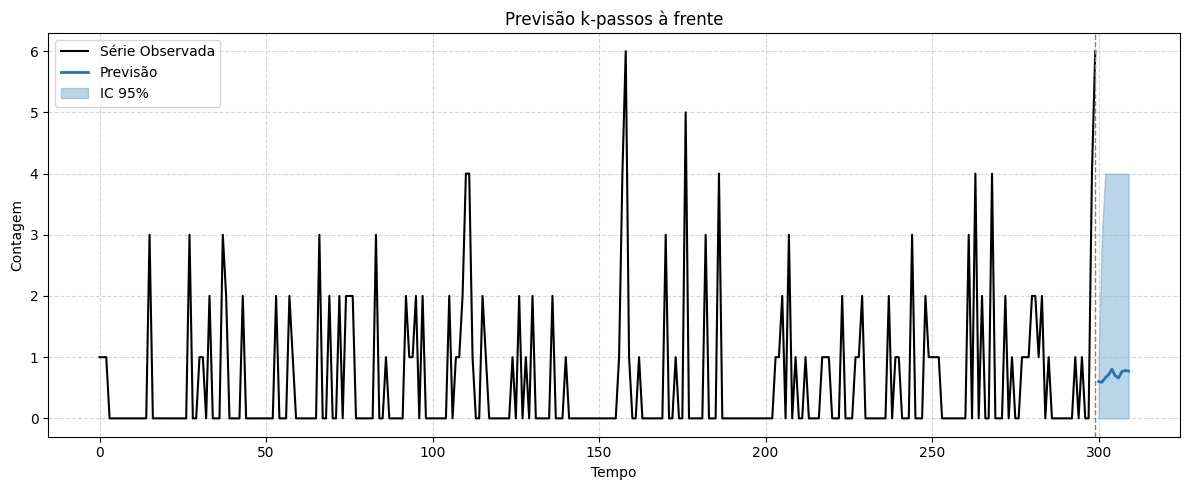

In [44]:
plot_forecast(y_obs, y_mean, np.array([y_ci_low, y_ci_high]))

# 2. GAS Hurdle Negative Binomial (GHNB)

O modelo hurdle binomial negativa (HNB) segue a mesma lógica do HP, porém a parte positiva é amostrada de uma **Binomial Negativa truncada em zero**.

A função de massa é:

$$
p(y_t \mid \mu_{t|t-1}, \alpha, \pi_{t|t-1}) =
\begin{cases}
\pi_{t|t-1}, & y_t = 0, \\[8pt]
(1 - \pi_{t|t-1})
\dfrac{
\Gamma(y_t + \alpha)
}{
\Gamma(y_t + 1)\Gamma(\alpha)
}
\left(
\frac{1}{1 + \frac{\mu_{t|t-1}}{\alpha}}
\right)^{\alpha}
\left(
1 - 
\frac{1}{
1 + \frac{\mu_{t|t-1}}{\alpha}
}
\right)^{y_t}
\dfrac{1}{
1 - \left(1 + \frac{\mu_{t|t-1}}{\alpha}\right)^{-\alpha}
},
& y_t > 0.
\end{cases}
$$

com  
- $\mu_{t|t-1} > 0$,  
- $\alpha > 0$,  
- $\pi_{t|t-1} \in (0,1)$.

## 2.1 Média e Variância

$$
\mathbb{E}_{t-1}[y_t]
=
\frac{\mu_{t|t-1}(1 - \pi_{t|t-1})}{
1 - \left(1 + \frac{\mu_{t|t-1}}{\alpha}\right)^{-\alpha}}
$$

$$
\operatorname{Var}_{t-1}[y_t]
=
\pi_{t|t-1}(1 - \pi_{t|t-1})
\left(
\frac{\mu_{t|t-1}}{
1 - \left(1 + \frac{\mu_{t|t-1}}{\alpha}\right)^{-\alpha}
}
\right)^2
+
(1 - \pi_{t|t-1})
\left[
\dfrac{
\mu_{t|t-1}\left(1 + \frac{\mu_{t|t-1}}{\alpha}\right)
}{
1 - \left(1 + \frac{\mu_{t|t-1}}{\alpha}\right)^{-\alpha}}
-
\left(1 + \frac{\mu_{t|t-1}}{\alpha}\right)^{-\alpha}
\left(
\frac{\mu_{t|t-1}}{
1 -
\left(1 + \frac{\mu_{t|t-1}}{\alpha}\right)^{-\alpha}}
\right)^2
\right]
\tag{21}
$$

In [19]:
# Função de simulação GAS-HNB
def simulate_ghnb(
    n_obs, 
    params, 
    seed=None, 
    lambda_max=50, 
    loglam_bounds=(-5, 4), 
    logitpi_bounds=(-6, 6)
):
    
    """
    Simula uma série temporal do modelo GAS Hurdle Negative Binomial (GHNB)
    com dinâmica para log(μ_t) e logit(π_t), conforme especificação teórica.

    Parâmetros:
    - n_obs: número de observações
    - params: dicionário com chaves:
        - omega1, alpha1, beta1: dinâmica de log(μ_t)
        - omega2, alpha2, beta2: dinâmica de logit(π_t)
        - sigma: desvio padrão do ruído (não usado aqui)
        - alpha: dispersão da NB
    - seed: semente aleatória

    Retorna:
    - y: série simulada
    - mu_t: sequência de médias da NB
    - pi_t: sequência de probabilidades de zero
    """

    if seed is not None:
        np.random.seed(seed)

    # Parâmetros da dinâmica para log(μ_t)
    omega1 = params['omega1']
    alpha1 = params['alpha1']
    beta1  = params['beta1']

    # Parâmetros da dinâmica para logit(π_t)
    omega2 = params['omega2']
    alpha2 = params['alpha2']
    beta2  = params['beta2']

    # Dispersão da NB (α > 0)
    alpha_disp = params['alpha']
    
    y = np.zeros(n_obs, dtype=int)
    mu_seq = np.zeros(n_obs)
    pi_seq = np.zeros(n_obs)

    # Inicialização dos estados latentes
    f1 = omega1  # log(μ_1)
    f2 = omega2  # logit(π_1)

    for t in range(n_obs):
        # Transformações
        mu_t = np.clip(np.exp(f1), 1e-6, lambda_max)  # μ_t > 0
        eta_pi = np.clip(f2, logitpi_bounds[0], logitpi_bounds[1])
        pi_t = 1 / (1 + np.exp(-eta_pi))  # logit⁻¹(f2)

        mu_seq[t] = mu_t
        pi_seq[t] = pi_t

        # Geração de y_t
        u = np.random.rand()
        if u < pi_t:
            y[t] = 0
        else:
            # Gera da NB truncada em zero
            while True:
                p_nb = alpha_disp / (alpha_disp + mu_t)
                z = np.random.negative_binomial(alpha_disp, p_nb)
                if z > 0:
                    y[t] = z
                    break

        # Score reparametrizado
        one_plus = 1 + mu_t / alpha_disp
        one_plus_pow_alpha = one_plus ** (-alpha_disp)

        if y[t] == 0:
            score1 = 1 - pi_t      # score para π
            score2 = 0             # score para μ
        else:
            numer = y[t] - mu_t * one_plus ** (-alpha_disp - 1)
            denom = 1 - one_plus_pow_alpha
            score1 = -pi_t
            score2 = numer / denom

        # Atualização dos estados
        f1 = omega1 + alpha1 * score2 + beta1 * f1
        f2 = omega2 + alpha2 * score1 + beta2 * f2

        # Clipping para estabilidade
        f1 = np.clip(f1, loglam_bounds[0], loglam_bounds[1])
        f2 = np.clip(f2, logitpi_bounds[0], logitpi_bounds[1])

    return y, mu_seq, pi_seq

In [20]:
n_obs = 200
series_list = []
param_list = []

rng = np.random.default_rng(42)

for i in range(5):
    print(f"Simulando série {i+1}")

    params_i = {
        # Dinâmica para log(mu_t)
        'omega1': rng.uniform(-0.5, 0.5),
        'alpha1': rng.uniform(0.05, 0.25),
        'beta1':  rng.uniform(0.5, 0.95),

        # Dinâmica para logit(pi_t)
        'omega2': rng.uniform(-1.0, 1.0),
        'alpha2': rng.uniform(0.05, 0.25),
        'beta2':  rng.uniform(0.5, 0.95),

        # Dispersão da NB
        'alpha': rng.uniform(2, 6)
    }

    y_i, mu_i, pi_i = simulate_ghnb(n_obs, params_i, seed=123+i)
    series_list.append((y_i, mu_i, pi_i))
    param_list.append(params_i)

Simulando série 1
Simulando série 2
Simulando série 3
Simulando série 4
Simulando série 5


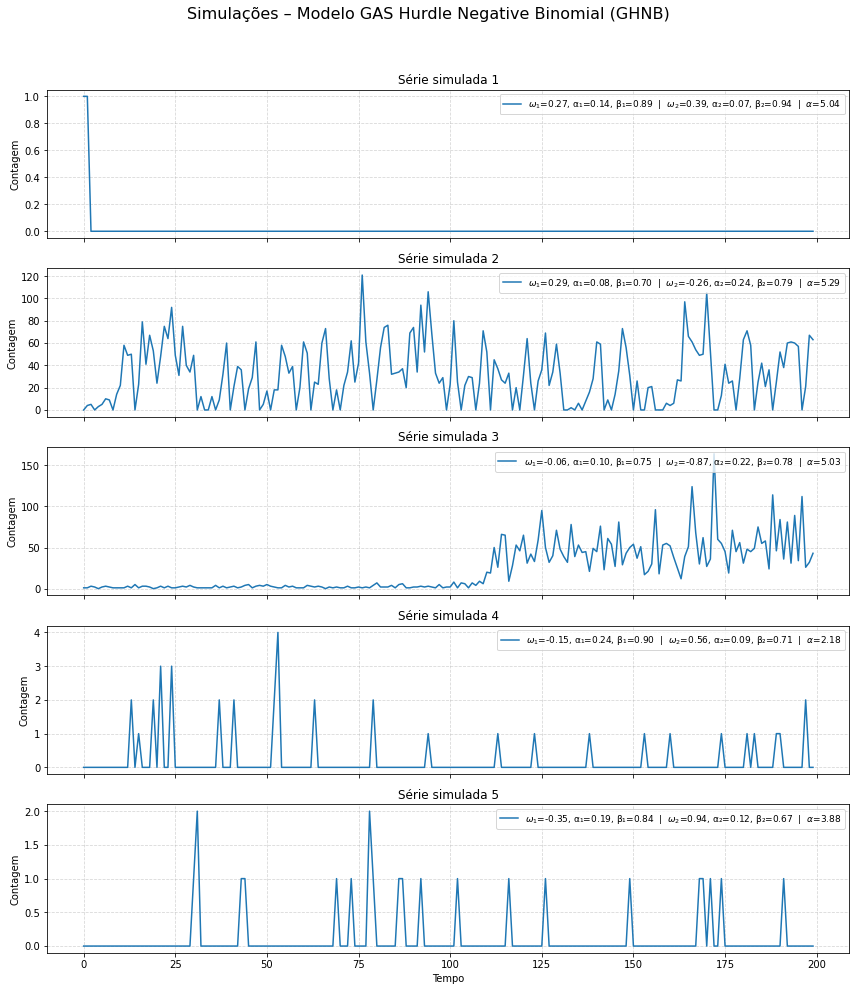

In [21]:
fig, axs = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

for i, (ax, (y, mu, pi), p) in enumerate(zip(axs, series_list, param_list)):
    
    legend_text = (
        f"$\\omega_1$={p['omega1']:.2f}, α₁={p['alpha1']:.2f}, β₁={p['beta1']:.2f}  |  "
        f"$\\omega_2$={p['omega2']:.2f}, α₂={p['alpha2']:.2f}, β₂={p['beta2']:.2f}  |  "
        f"$α$={p['alpha']:.2f}"
    )

    ax.plot(y, label=legend_text, lw=1.5)
    ax.set_ylabel("Contagem")
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title(f"Série simulada {i+1}")

axs[-1].set_xlabel("Tempo")
fig.suptitle("Simulações – Modelo GAS Hurdle Negative Binomial (GHNB)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [31]:
def ghnb_scores(y, mu, pi, alpha):
    """
    Retorna os scores reparametrizados (tilde-s) do modelo GHNB.
    Score é um VETOR de dimensão 2: [score_pi , score_mu]
    conforme fórmulas (22) e (23).
    """
    if y == 0:
        score_pi = 1 - pi
        score_mu = 0.0
    else:
        A = 1 + mu / alpha
        denom = 1 - A ** (-alpha)
        numer = y - mu * A ** (-(alpha + 1))
        score_pi = -pi
        score_mu = numer / denom

    return score_pi, score_mu


In [32]:
def ghnb_filter_paths(params, y, logmu_bounds=(-5, 4), logitpi_bounds=(-6, 6)):
    """
    Constrói os caminhos filtrados de log(μ_t) e logit(π_t),
    e retorna também os scores reparametrizados.
    """
    omega1, alpha1, beta1, omega2, alpha2, beta2, log_alpha = params
    alpha_nb = np.exp(log_alpha)

    T = len(y)
    f1 = np.zeros(T)   # log(μ_t)
    f2 = np.zeros(T)   # logit(π_t)

    mu_t = np.zeros(T)
    pi_t = np.zeros(T)
    score_pi = np.zeros(T)
    score_mu = np.zeros(T)

    for t in range(T):
        mu_t[t] = np.exp(f1[t])
        pi_t[t] = expit(f2[t])

        if t < T - 1:
            score_pi[t], score_mu[t] = ghnb_scores(y[t], mu_t[t], pi_t[t], alpha_nb)

            # Atualização GAS
            f1_t1 = omega1 + alpha1 * score_mu[t] + beta1 * f1[t]
            f2_t1 = omega2 + alpha2 * score_pi[t] + beta2 * f2[t]

            f1[t + 1] = np.clip(f1_t1, *logmu_bounds)
            f2[t + 1] = np.clip(f2_t1, *logitpi_bounds)

    return mu_t, pi_t, f1, f2, score_pi, score_mu

In [33]:
def neg_loglik_ghnb(params, y):
    """
    Log-verossimilhança negativa do modelo GAS Hurdle Negative Binomial (GHNB),
    com atualização das componentes log(μ_t) e logit(π_t).
    """
    omega1, alpha1, beta1, omega2, alpha2, beta2, log_alpha = params
    alpha_nb = np.exp(log_alpha)

    # Restrições básicas de estacionariedade e estabilidade
    if not (0 < beta1 < 1 and 0 < beta2 < 1):
        return np.inf
    if not (0 <= alpha1 <= 1 and 0 <= alpha2 <= 1):
        return np.inf

    mu_t, pi_t, _, _, _, _ = ghnb_filter_paths(params, y)

    loglik = 0.0
    for t in range(len(y)):
        mu = mu_t[t]
        pi = pi_t[t]
        A = 1 + mu / alpha_nb
        r = alpha_nb

        if y[t] == 0:
            loglik += np.log(pi)
        else:
            # Parte da NB
            log_p_nb = (
                gammaln(y[t] + r) - gammaln(r) - gammaln(y[t] + 1)
                + r * np.log(r / (r + mu))
                + y[t] * np.log(mu / (r + mu))
            )
            # Truncação em zero
            log_trunc = -np.log(1 - (r / (r + mu)) ** r)
            log_p_nb += log_trunc

            loglik += np.log(1 - pi) + log_p_nb

    return -loglik

In [34]:
indice_serie = 4
y_obs_nb = series_list[indice_serie][0]

init_params = [
    0.1, 0.1, 0.8,    # ω1, α1, β1
    0.1, 0.1, 0.8,    # ω2, α2, β2
    np.log(3.0)       # log(alpha_disp)
]

result_nb = minimize(
    neg_loglik_ghnb,
    init_params,
    args=(y_obs_nb,),
    method='L-BFGS-B'
)

omega1_hat, alpha1_hat, beta1_hat, omega2_hat, alpha2_hat, beta2_hat, log_alpha_hat = result_nb.x
alpha_disp_hat = np.exp(log_alpha_hat)

/opt/python37/lib/python3.7/site-packages/scipy/optimize/_numdiff.py:497: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


In [35]:
parametros_originais = param_list[indice_serie]

print("Parâmetros estimados:")
print(f"ω1={omega1_hat:.4f}, α1={alpha1_hat:.4f}, β1={beta1_hat:.4f}")
print(f"ω2={omega2_hat:.4f}, α2={alpha2_hat:.4f}, β2={beta2_hat:.4f}")
print(f"α (disp NB)={alpha_disp_hat:.4f}")

print("-" * 50)

print("Parâmetros originais:")
print(f"ω1={parametros_originais['omega1']:.4f}, α1={parametros_originais['alpha1']:.4f}, β1={parametros_originais['beta1']:.4f}")
print(f"ω2={parametros_originais['omega2']:.4f}, α2={parametros_originais['alpha2']:.4f}, β2={parametros_originais['beta2']:.4f}")
# print(f"α (disp NB)={alpha_disp_hat:.4f}")

Parâmetros estimados:
ω1=0.1000, α1=0.1000, β1=0.8000
ω2=0.1000, α2=0.1000, β2=0.8000
α (disp NB)=3.0000
--------------------------------------------------
Parâmetros originais:
ω1=-0.3457, α1=0.1866, β1=0.8351
ω2=0.9350, α2=0.1152, β2=0.6667


In [38]:
# Parâmetros estimados
params_hat = [
    omega1_hat, alpha1_hat, beta1_hat,
    omega2_hat, alpha2_hat, beta2_hat,
    log_alpha_hat
]

# Estimar caminhos
mu_hat, pi_hat, _, _, score_pi, score_mu = ghnb_filter_paths(params_hat, y_obs)

# Valor ajustado (esperança condicional)
y_hat = (1 - pi_hat) * mu_hat

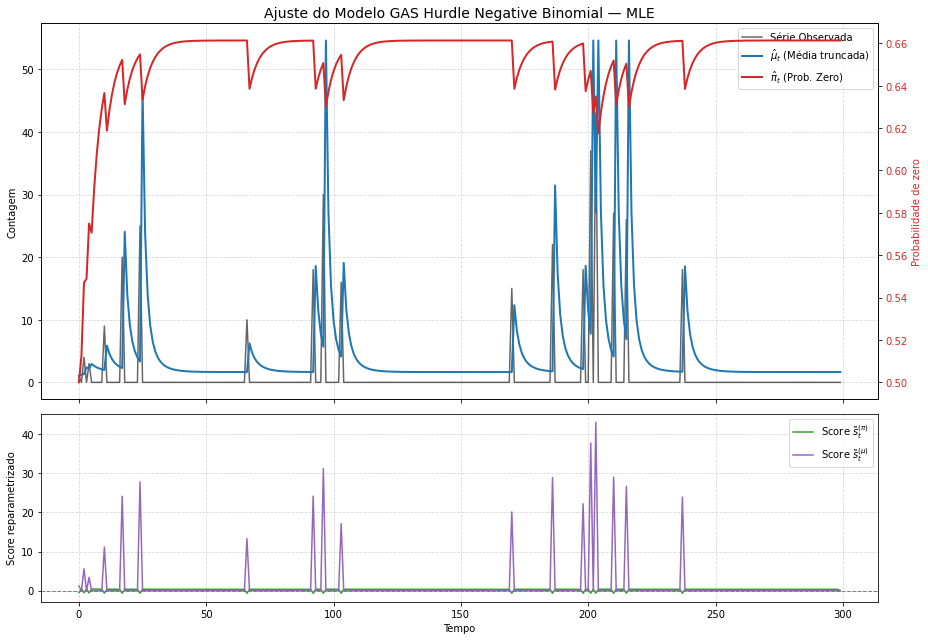

In [40]:
fig, axs = plt.subplots(2, 1, figsize=(13, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# === GRÁFICO 1: série observada + lambda + pi ===
ax1 = axs[0]

# Eixo esquerdo: y_obs e mu_hat
ax1.plot(y_obs, label='Série Observada', lw=1.5, color='black', alpha=0.6)
ax1.plot(mu_hat, label=r'$\hat{\mu}_t$ (Média truncada)', lw=2, color='tab:blue')
ax1.set_ylabel("Contagem", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle='--', alpha=0.5)

# Eixo direito: pi_hat
ax2 = ax1.twinx()
ax2.plot(pi_hat, label=r'$\hat{\pi}_t$ (Prob. Zero)', lw=2, color='tab:red')
ax2.set_ylabel("Probabilidade de zero", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Legenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Título
axs[0].set_title("Ajuste do Modelo GAS Hurdle Negative Binomial — MLE", fontsize=14)


# === GRÁFICO 2: Scores ===
axs[1].plot(score_pi, label=r'Score $\tilde{s}^{(\pi)}_t$', lw=1.5, color='tab:green')
axs[1].plot(score_mu, label=r'Score $\tilde{s}^{(\mu)}_t$', lw=1.5, color='tab:purple')
axs[1].axhline(0, ls='--', color='gray', lw=1)
axs[1].set_ylabel("Score reparametrizado")
axs[1].set_xlabel("Tempo")
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
def diagnostics_ghnb(y_obs, lambda_hat, pi_hat, r_hat, title='Diagnóstico GHNB'):
    """
    Diagnósticos do modelo GAS Hurdle Negative Binomial
    - PIT com hurdle
    - Resíduo quantílico (QQ plot)
    """
    n = len(y_obs)
    pit = np.zeros(n)
    quant_resid = np.zeros(n)

    for t in range(n):
        y = y_obs[t]
        λ = lambda_hat[t]
        π = pi_hat[t]
        r = r_hat

        # p = r / (r + λ)
        p_nb = r / (r + λ)

        if y == 0:
            pit[t] = uniform.rvs(0, π)
        else:
            # CDF truncada da NB em zero
            def cdf_ztnb(k):
                numer = nbinom.cdf(k, r, p_nb) - nbinom.pmf(0, r, p_nb)
                denom = 1 - nbinom.pmf(0, r, p_nb)
                return numer / denom

            pit_nb = cdf_ztnb(y - 1) + np.random.uniform() * (cdf_ztnb(y) - cdf_ztnb(y - 1))
            pit[t] = π + (1 - π) * pit_nb

    # Resíduo quantílico
    quant_resid = norm.ppf(pit)

    # Plots
    fig, axs = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=16)

    # PIT
    sns.histplot(pit, bins=20, kde=False, stat='density', ax=axs[0], color='steelblue')
    axs[0].plot([0, 1], [1, 1], 'r--')
    axs[0].set_title("Histograma do PIT")
    axs[0].set_xlabel("PIT")
    axs[0].set_ylabel("Densidade")

    # QQ-plot dos resíduos quantílicos
    probplot(quant_resid, dist="norm", plot=axs[1])
    axs[1].set_title("QQ-Plot dos Resíduos Quantílicos")

    plt.tight_layout()
    plt.show()

    return pit, quant_resid

In [ ]:
pit_ghnb, quant_resid_ghnb = diagnostics_ghnb(
    y_obs=y_obs,
    lambda_hat=lambda_hat,
    pi_hat=pi_hat,
    r_hat=r_hat,
    title='Diagnóstico da Série 1 (GHNB)'
)

## Previsao $k$ passos a frente

In [ ]:
def forecast_ghnb(
    f1_last, 
    f2_last, 
    params, 
    k=10, 
    n_sim=5000,
    loglam_bounds=(-6, 6), 
    logitpi_bounds=(-6, 6)
):
    """
    Previsão k-passos à frente por simulação Monte Carlo para GHNB.
    """

    omega1, alpha1, beta1 = params["omega1"], params["alpha1"], params["beta1"]
    omega2, alpha2, beta2 = params["omega2"], params["alpha2"], params["beta2"]
    alpha_disp = params["alpha"]

    forecasts = np.zeros((n_sim, k))

    for s in range(n_sim):

        f1 = f1_last
        f2 = f2_last

        for h in range(k):

            mu = np.exp(f1)
            mu = np.clip(mu, 1e-6, 50)

            pi = 1 / (1 + np.exp(-f2))
            pi = np.clip(pi, 1e-6, 1-1e-6)

            # Simulação hurdle NB
            u = np.random.rand()
            if u < pi:
                y_sim = 0
            else:
                while True:
                    p_nb = alpha_disp / (alpha_disp + mu)
                    y_sim = np.random.negative_binomial(alpha_disp, p_nb)
                    if y_sim > 0:
                        break

            forecasts[s, h] = y_sim

            # Score reparametrizado
            if y_sim == 0:
                score1 = 1 - pi
                score2 = 0
            else:
                one_plus = 1 + mu / alpha_disp
                score1 = -pi
                score2 = (y_sim - mu * one_plus**(-(alpha_disp+1))) / (1 - one_plus**(-alpha_disp))

            # GAS update
            f1 = omega1 + alpha1 * score2 + beta1 * f1
            f2 = omega2 + alpha2 * score1 + beta2 * f2

            f1 = np.clip(f1, loglam_bounds[0], loglam_bounds[1])
            f2 = np.clip(f2, logitpi_bounds[0], logitpi_bounds[1])

    mean_forecast = forecasts.mean(axis=0)
    ic = np.percentile(forecasts, [2.5, 97.5], axis=0)

    return mean_forecast, ic

In [ ]:
def forecast_ghnb(f_last, params, k=10, n_sim=5000, loglam_bounds=(-5, 4)):
    """
    Previsão k-passos à frente para o modelo GAS Hurdle NB via simulação.

    Parâmetros:
    - f_last: último valor de f_t (log-lambda)
    - params: dicionário com parâmetros estimados: omega, alpha, beta, rho, r
    - k: horizonte de previsão
    - n_sim: número de simulações para IC
    - loglam_bounds: limites para clipping de f

    Retorna:
    - forecast_mean: valor médio da previsão para cada passo
    - forecast_ic: intervalo de confiança 95% (inferior e superior)
    """
    omega = params['omega']
    alpha = params['alpha']
    beta  = params['beta']
    rho   = params['rho']
    r     = params['r']

    forecasts = np.zeros((n_sim, k))

    for i in range(n_sim):
        f_t = f_last
        for h in range(k):
            lambda_t = np.exp(f_t)
            lambda_t = np.clip(lambda_t, 1e-6, 50)

            p_zero = 1 / (1 + np.exp(-rho))  # hurdle
            p_nb   = r / (r + lambda_t)

            # Simular hurdle NB
            u = np.random.rand()
            if u < p_zero:
                y_sim = 0
            else:
                # Zero-truncated NB
                while True:
                    y_sim = np.random.negative_binomial(r, p_nb)
                    if y_sim > 0:
                        break

            forecasts[i, h] = y_sim

            # GAS update (usando score de NB)
            score = y_sim - lambda_t
            f_t = omega + alpha * score + beta * f_t
            f_t = np.clip(f_t, loglam_bounds[0], loglam_bounds[1])

    # Estatísticas
    forecast_mean = np.mean(forecasts, axis=0)
    forecast_ic = np.percentile(forecasts, [2.5, 97.5], axis=0)

    return forecast_mean, forecast_ic

In [ ]:
# Último f_t filtrado do lambda_hat
f_last = np.log(lambda_hat[-1])

params_hat = {
    'omega': omega_hat,
    'alpha': alpha_hat,
    'beta': beta_hat,
    'rho': rho_hat,
    'r': r_hat
}

k = 10  # número de passos à frente
forecast_mean, forecast_ic = forecast_ghnb(f_last, params_hat, k=k)

In [ ]:
# Plotando
plt.figure(figsize=(10, 5))
plt.plot(range(len(y_obs)), y_obs, label='Série observada')
plt.plot(range(len(y_obs), len(y_obs) + k), forecast_mean, label='Previsão média', marker='o')
plt.fill_between(
    range(len(y_obs), len(y_obs) + k),
    forecast_ic[0], 
    forecast_ic[1],
    color='gray', 
    alpha=0.3, 
    label='IC 95%'
)
plt.xlabel('Tempo')
plt.ylabel('Contagem')
plt.title(f'Previsão {k}-passos à frente – GHNB')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Série real

Usaremos a base de quantidade de ocorrência de homicídios.

In [18]:
# Caminho base (arquivo atual)
pasta_atual = Path().resolve()

# Caminho relativo para a planilha
dados_seguranca_caminho = pasta_atual.parent.parent / "raw_databases" / "dados_seguranca.csv"

database = pd.read_csv(dados_seguranca_caminho)

database.dtypes

ano                                         int64
mes                                         int64
id_cisp                                     int64
id_aisp                                     int64
id_risp                                     int64
                                            ...  
quantidade_policial_civil_morto_servico     int64
quantidade_registro_ocorrencia              int64
tipo_fase                                  object
unidade_territorial                        object
regiao_territorial                         object
Length: 63, dtype: object

In [19]:
database['date'] = database.apply(lambda row: dt.datetime(row['ano'], row['mes'], 1), axis=1)

database = database.set_index('date')

locations = database[['id_cisp','unidade_territorial']].set_index('id_cisp')['unidade_territorial'].to_dict()

In [20]:
var = 'quantidade_tentativa_homicidio'

data = database.loc[database.id_cisp==10, [var]]

# metadados
pd.DataFrame(index=['Metadados'], data={
    'Fonte':'Banco de Dados do Instituo de Segurança Pública do Rio de Janeiro (ISP)', 
    'Unidade':'Quantidade de ocorrências',
    'Período da série': '{} a {}'.format(database.index[0].strftime('%d/%m/%Y'), database.index[-1].strftime('%d/%m/%Y'))
}).T

,Metadados
Fonte,Banco de Dados do Instituo de Segurança Públic...
Unidade,Quantidade de ocorrências
Período da série,01/01/2003 a 01/10/2025


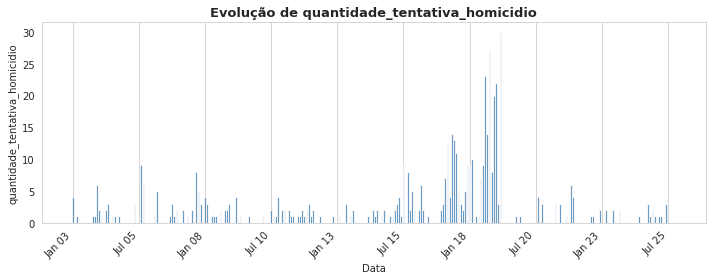

In [21]:
sns.set_style("whitegrid")  # Estilo visual limpo

# Inicializa figura e eixo único
fig, ax = plt.subplots(figsize=(10, 4))

# Gráfico de barras
ax.bar(np.arange(data.shape[0]), data[var], color="steelblue", alpha=0.8)

# Ticks de data no eixo X
tick_freq = 30
ticks = np.arange(0, data.shape[0], tick_freq)
ax.set_xticks(ticks)
ax.set_xticklabels(data.index[ticks].strftime("%b %y"), rotation=45, ha="right")

# Títulos e rótulos
ax.set_title(f"Evolução de {var}", fontsize=13, weight="bold")
ax.set_xlabel("Data")
ax.set_ylabel(var)

# Grade discreta no eixo Y
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Ajustando ao GHP

In [22]:
y_obs = data.values.reshape(-1)
n = len(y_obs)

# Chute inicial sensato
x0 = np.array([0.1, 0.1, 0.9, 0.1, 0.1, 0.9])

bounds = [
    (-2, 2),
    (-0.95, 0.95),
    (0, 1),
    (-2, 2),
    (-0.95, 0.95),
    (0, 1)
]

result = minimize(
    neg_loglik_ghp,
    x0,
    args=(y_obs,),
    method="L-BFGS-B",
    bounds=bounds
)

/opt/python37/lib/python3.7/site-packages/scipy/optimize/_numdiff.py:497: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


In [23]:
theta_hat = result.x

theta_hat_dict = {
    'delta_lambda': theta_hat[0],
    'beta_lambda': theta_hat[1],
    'rho_lambda': theta_hat[2],
    'delta_pi': theta_hat[3],
    'beta_pi': theta_hat[4],
    'rho_pi':  theta_hat[5],
}

lambda_hat, pi_hat, f_lambda_hat, f_pi_hat, score_lambda, score_pi = filter_ghp(theta_hat_dict, y_obs)

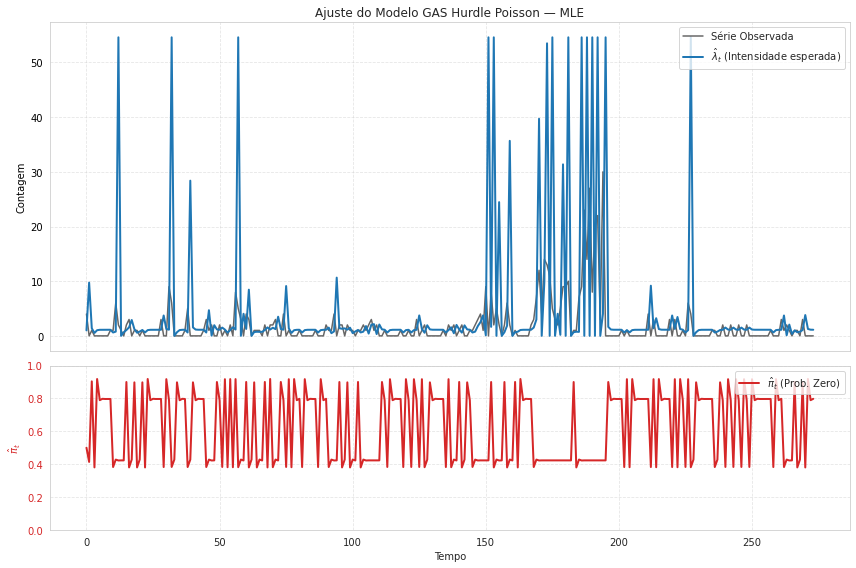

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

# --- Gráfico superior: y_obs e lambda_hat ---
ax1.plot(y_obs, label='Série Observada', lw=1.5, color='black', alpha=0.6)
ax1.plot(lambda_hat, label=r'$\hat{\lambda}_t$ (Intensidade esperada)', lw=2, color='tab:blue')
ax1.set_ylabel("Contagem", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')
ax1.set_title("Ajuste do Modelo GAS Hurdle Poisson — MLE")

# --- Gráfico inferior: pi_hat ---
ax2.plot(pi_hat, label=r'$\hat{\pi}_t$ (Prob. Zero)', lw=2, color='tab:red')
ax2.set_xlabel("Tempo")
ax2.set_ylabel(r"$\hat{\pi}_t$", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

/opt/python37/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in sqrt
/opt/python37/lib/python3.7/site-packages/numpy/lib/function_base.py:2536: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


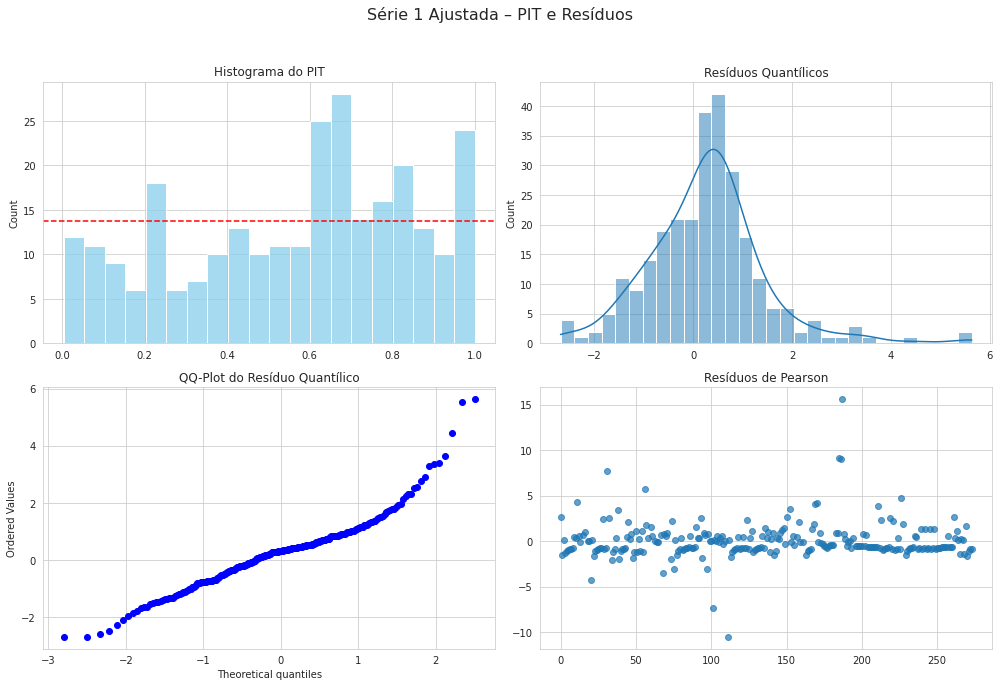

In [61]:
# Diagnóstico
diag = diagnostics_ghp(y_obs, lambda_hat, pi_hat, title='Série 1 Ajustada')

In [41]:
# === codigo refatorado ===
from typing import Tuple, Dict
import numpy as np
from scipy.special import expit, gammaln

# ----------------------------
# UTILS
# ----------------------------
def sigmoid(x):
    return expit(x)

def clip_logit(x, bounds=(-6, 6)):
    return np.clip(x, *bounds)

def clip_exp(x, bounds=(-5, 4)):
    return np.clip(np.exp(x), np.exp(bounds[0]), np.exp(bounds[1]))

In [ ]:
# ----------------------------
# UTILS
# ----------------------------
def sigmoid(x):
    return expit(x)

def clip_logit(x, bounds=(-6, 6)):
    return np.clip(x, *bounds)

def clip_exp(x, bounds=(-5, 4)):
    return np.clip(np.exp(x), np.exp(bounds[0]), np.exp(bounds[1]))

# --------------------------------------------------
# Scores Reparametrizados
# --------------------------------------------------

def score_ghp(y, lam, pi):
    if y == 0:
        return 1 - pi, -lam
    else:
        trunc = lam * np.exp(-lam) / (1 - np.exp(-lam))
        return -pi, y - trunc

def score_ghnb(y, mu, pi, alpha):
    if y == 0:
        return 1 - pi, 0.0
    else:
        denom = 1 - (1 + mu / alpha) ** (-alpha)
        part = mu * (1 + mu / alpha) ** (-(alpha + 1))
        score_mu = (y - part) / denom
        return -pi, score_mu

# --------------------------------------------------
# Simulador Geral GAS Hurdle
# --------------------------------------------------

def simulate_gas_model(n_obs, params, model='ghp', seed=None, mu_max=50, logmu_bounds=(-5, 4)):
    if seed is not None:
        np.random.seed(seed)

    omega1 = params['omega1']
    alpha1 = params['alpha1']
    beta1  = params['beta1']
    omega2 = params['omega2']
    alpha2 = params['alpha2']
    beta2  = params['beta2']
    alpha_nb = np.exp(params['log_alpha']) if model == 'ghnb' else None

    y = np.zeros(n_obs, dtype=int)
    mu = np.zeros(n_obs)
    pi = np.zeros(n_obs)
    f1 = omega1
    f2 = omega2

    for t in range(n_obs):
        mu_t = np.clip(np.exp(f1), 1e-6, mu_max)
        pi_t = expit(f2)
        mu[t] = mu_t
        pi[t] = np.clip(pi_t, 1e-6, 1 - 1e-6)

        u = np.random.rand()
        if u < pi[t]:
            y[t] = 0
        else:
            if model == 'ghp':
                while True:
                    z = np.random.poisson(mu_t)
                    if z > 0:
                        y[t] = z
                        break
            elif model == 'ghnb':
                while True:
                    p_nb = alpha_nb / (alpha_nb + mu_t)
                    z = np.random.negative_binomial(alpha_nb, p_nb)
                    if z > 0:
                        y[t] = z
                        break

        if model == 'ghp':
            score_pi, score_mu = score_ghp(y[t], mu_t, pi[t])
        elif model == 'ghnb':
            score_pi, score_mu = score_ghnb(y[t], mu_t, pi[t], alpha_nb)

        f1 = np.clip(omega1 + alpha1 * score_mu + beta1 * f1, *logmu_bounds)
        f2 = np.clip(omega2 + alpha2 * score_pi + beta2 * f2, -6, 6)

    return y, mu, pi

# --------------------------------------------------
# Filtro Geral GAS Hurdle (caminhos filtrados)
# --------------------------------------------------

def filter_gas_model(params, y, model='ghp', logmu_bounds=(-5, 4), logitpi_bounds=(-6, 6)):
    omega1, alpha1, beta1, omega2, alpha2, beta2, log_alpha = params
    alpha_nb = np.exp(log_alpha) if model == 'ghnb' else None

    T = len(y)
    f1 = np.zeros(T)
    f2 = np.zeros(T)
    mu_t = np.zeros(T)
    pi_t = np.zeros(T)
    score_mu = np.zeros(T)
    score_pi = np.zeros(T)

    for t in range(T):
        mu_t[t] = np.exp(f1[t])
        pi_t[t] = expit(f2[t])

        if t < T - 1:
            if model == 'ghp':
                score_pi[t], score_mu[t] = score_ghp(y[t], mu_t[t], pi_t[t])
            elif model == 'ghnb':
                score_pi[t], score_mu[t] = score_ghnb(y[t], mu_t[t], pi_t[t], alpha_nb)

            f1[t+1] = np.clip(omega1 + alpha1 * score_mu[t] + beta1 * f1[t], *logmu_bounds)
            f2[t+1] = np.clip(omega2 + alpha2 * score_pi[t] + beta2 * f2[t], *logitpi_bounds)

    return mu_t, pi_t, f1, f2, score_mu, score_pi

# --------------------------------------------------
# Log-Verossimilhança Geral (GHP / GHNB)
# --------------------------------------------------

def loglike_gas_model(params, y, model='ghp'):
    omega1, alpha1, beta1, omega2, alpha2, beta2, log_alpha = params
    alpha_nb = np.exp(log_alpha) if model == 'ghnb' else None

    if not (0 < beta1 < 1 and 0 < beta2 < 1):
        return np.inf

    mu_t, pi_t, _, _, _, _ = filter_gas_model(params, y, model)

    loglike = 0.0
    for t in range(len(y)):
        mu = mu_t[t]
        pi0 = pi_t[t]

        if y[t] == 0:
            if model == 'ghp':
                loglike += np.log(pi0 + (1 - pi0) * np.exp(-mu))
            elif model == 'ghnb':
                trunc = 1 - (1 + mu / alpha_nb) ** (-alpha_nb)
                loglike += np.log(pi0 + (1 - pi0) * (1 - trunc))
        else:
            if model == 'ghp':
                pois = y[t] * np.log(mu) - mu - gammaln(y[t] + 1)
                pois_trunc = pois - np.log(1 - np.exp(-mu))
                loglike += np.log(1 - pi0) + pois_trunc
            elif model == 'ghnb':
                logpmf = (
                    gammaln(y[t] + alpha_nb) - gammaln(y[t] + 1) - gammaln(alpha_nb)
                    + alpha_nb * np.log(alpha_nb / (alpha_nb + mu))
                    + y[t] * np.log(mu / (alpha_nb + mu))
                )
                trunc_corr = np.log(1 - (alpha_nb / (alpha_nb + mu)) ** alpha_nb)
                loglike += np.log(1 - pi0) + logpmf - trunc_corr

    return -loglike

In [ ]:
def forecast_gas_model(f1_last, f2_last, params, k=10, n_sim=5000, model='ghp',
                       logmu_bounds=(-5, 4), logitpi_bounds=(-6, 6)):
    """
    Simula previsões k-passos à frente para o modelo GAS (GHP ou GHNB).

    Parâmetros:
    - f1_last, f2_last: últimos valores dos estados latentes (log-μ, logit-π)
    - params: parâmetros estimados
    - k: horizonte de previsão
    - n_sim: número de simulações para intervalos de confiança
    - model: 'ghp' ou 'ghnb'
    - bounds: limites para clipping dos estados latentes

    Retorna:
    - forecast_mean: média preditiva k-passos
    - forecast_ic: intervalo de confiança 95%
    """
    if model == 'ghp':
        omega1, alpha1, beta1, omega2, alpha2, beta2 = params
        r = None
    elif model == 'ghnb':
        omega1, alpha1, beta1, omega2, alpha2, beta2, log_alpha = params
        r = np.exp(log_alpha)
    else:
        raise ValueError("Modelo inválido. Use 'ghp' ou 'ghnb'.")

    forecasts = np.zeros((n_sim, k))

    for i in range(n_sim):
        f1_t = f1_last
        f2_t = f2_last

        for h in range(k):
            mu_t = np.exp(f1_t)
            pi_t = expit(f2_t)

            u = np.random.rand()
            if u < pi_t:
                y_sim = 0
            else:
                if model == 'ghp':
                    while True:
                        y_sim = np.random.poisson(mu_t)
                        if y_sim > 0:
                            break
                elif model == 'ghnb':
                    p_nb = r / (r + mu_t)
                    while True:
                        y_sim = np.random.negative_binomial(r, p_nb)
                        if y_sim > 0:
                            break

            forecasts[i, h] = y_sim

            if y_sim == 0:
                score_pi = 1 - pi_t
                score_mu = -mu_t if model == 'ghp' else 0.0
            else:
                score_pi = -pi_t
                if model == 'ghp':
                    trunc = mu_t * np.exp(-mu_t) / (1 - np.exp(-mu_t))
                    score_mu = y_sim - trunc
                elif model == 'ghnb':
                    den = 1 - (1 + mu_t / r) ** (-r)
                    num = mu_t * (1 + mu_t / r) ** (-(r + 1))
                    score_mu = (y_sim - num) / den

            f1_t1 = omega1 + alpha1 * score_mu + beta1 * f1_t
            f2_t1 = omega2 + alpha2 * score_pi + beta2 * f2_t

            f1_t = np.clip(f1_t1, *logmu_bounds)
            f2_t = np.clip(f2_t1, *logitpi_bounds)

    forecast_mean = np.mean(forecasts, axis=0)
    forecast_ic = np.percentile(forecasts, [2.5, 97.5], axis=0)

    return forecast_mean, forecast_ic


forecast_mean, forecast_ic = forecast_gas_model(
    f1_last=f1_hat[-1],
    f2_last=f2_hat[-1],
    params=parametros_estimados,
    k=10,
    n_sim=5000,
    model='ghp'  # ou 'ghnb'
)